In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gsw
import os
import pandas as pd
from multiprocessing import pool

In [2]:
# data source : HadISST dataset
# ds=xr.open_dataset('/glade/campaign/univ/ugit0034/HadISST/HadISST_sst.nc')
ds=xr.open_dataset('/glade/campaign/univ/ugit0034/cmip6/IPSL-CM6A-LR/TS/TS_IPSL-CM6A-LR_19652100_SSP126.nc')

In [3]:
# get coordinates
# x=ds.longitude
# y=ds.latitude
x=ds.lon
y=ds.lat
xx,yy=np.meshgrid(x,y)
# cosine of latitude as area weight factor
cosy=np.cos(np.deg2rad(yy))

In [4]:
# assign NaN to the missing data
sst = np.where(ds.CT.isel(depth=0)<-100,np.nan,ds.CT.isel(depth=0))

/glade/derecho/scratch/qzhang459/tmp/ipykernel_9648/931994802.py:2: RuntimeWarning: Mean of empty slice
  sstm = np.nanmean(sst,axis=0)


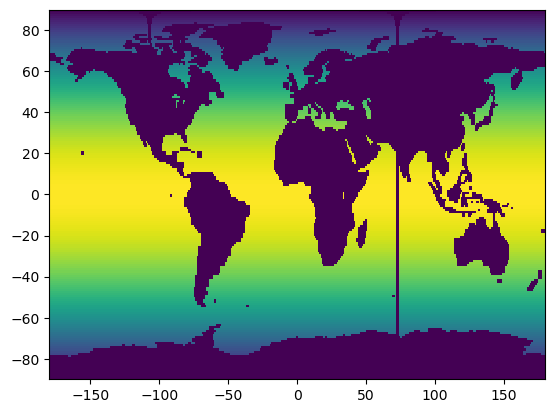

In [5]:
# calculate climatological SST in preparation for the global land-ocean mask
sstm = np.nanmean(sst,axis=0)
#plt.pcolormesh(x,y,sstm)
#
# plot the area factor 
mask=np.where(np.isnan(sstm),0,1)
plt.pcolormesh(x,y,mask*cosy)

In [6]:
# define the mask as DataArray
w=xr.DataArray(data=cosy*mask,name='w',dims=['lat','lon'],
               coords={'lat':y,'lon':x})
time=ds.time
# define the SST DataArray
temp=xr.DataArray(data=sst,name='sst',dims=['time','lat','lon'],
               coords={'time':time,'lat':y,'lon':x})

In [7]:
# running mean filter
def movmean(data,w):
    W=np.ones(w)/w
    return np.convolve(data,W,'same')

In [8]:
# define the global mean temperature as area weighted mean SST
gsst=temp.weighted(w).mean(('lat','lon'))
gsstm=movmean(gsst,12)

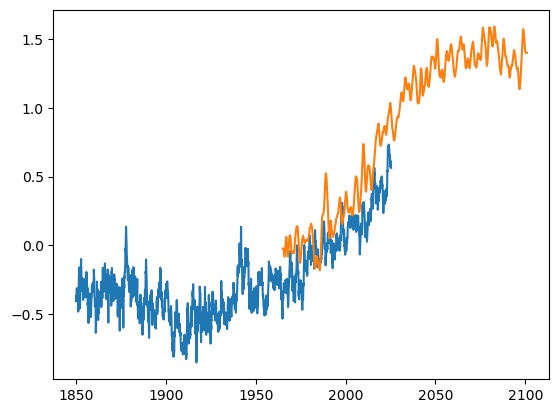

In [15]:
time=np.arange(1965,2101,1/12)
# plt.plot(time[6:-6],gsstm[6:-6],label='12 month running mean')
plt.plot(time1,SST,label='NOAAGlobalTemp v6')
plt.plot(time,gsstm_rolled,label='SST')

In [9]:
gsstm_rolled = gsst.rolling(time=12, center=True).mean()-gsst.sel(time=slice('1965-01','1974-12')).mean().to_numpy()
gsstm_rolled[:6] = gsstm_rolled[6]    # first 6 = first valid mean
gsstm_rolled[-6:] = gsstm_rolled[-7]

In [10]:
gsstm_rolled

<xarray.DataArray 'sst' (time: 1632)> Size: 13kB
array([-0.02248974, -0.02248974, -0.02248974, ...,  1.39913587,
        1.39913587,  1.39913587], shape=(1632,))
Coordinates:
  * time     (time) datetime64[ns] 13kB 1965-01-16T12:00:00 ... 2100-12-16T12...

In [16]:
GMT=gsstm_rolled.to_numpy()
print(GMT.size)

1632


In [17]:
gsstm0 = gsstm_rolled
# da=xr.DataArray(data=gsstm0,name='sst',dims=['time'],coords={'time':time})
ds=gsstm0.to_dataset()
ds.to_netcdf('IPSL-CM6A-LR_Global_SST_SSP126.nc')

In [8]:
# running mean filter
def movmean(data,w):
    W=np.ones(w)/w
    return np.convolve(data,W,'same')

In [9]:
# Butterworth bandpass filter
from scipy.signal import butter, filtfilt
b,a = butter(4, .2, btype='low', fs=12)
# define low-pass filtered global SST
gsstlp=filtfilt(b,a,gsst)

In [11]:
# NOAA Global SST dataset
# National Center For Environmental Information
# https://www.ncei.noaa.gov/products/land-based-station/noaa-global-temp
df=pd.read_csv('/glade/derecho/scratch/qzhang459/EMU2/aravg.mon.ocean.90S.90N.v6.0.0.202505.csv')

In [12]:
df

,year,month,SST
0,1850,1,-0.399488
1,1850,2,-0.367293
2,1850,3,-0.407154
3,1850,4,-0.393352
4,1850,5,-0.384094
...,...,...,...
2100,2025,1,0.614028
2101,2025,2,0.588825
2102,2025,3,0.600533
2103,2025,4,0.565335


In [13]:
time1=np.arange(1850,2025+4.5/12,1/12)

In [14]:
SST=df['SST'].to_numpy()
print(time1.size,SST.size)

2105 2105


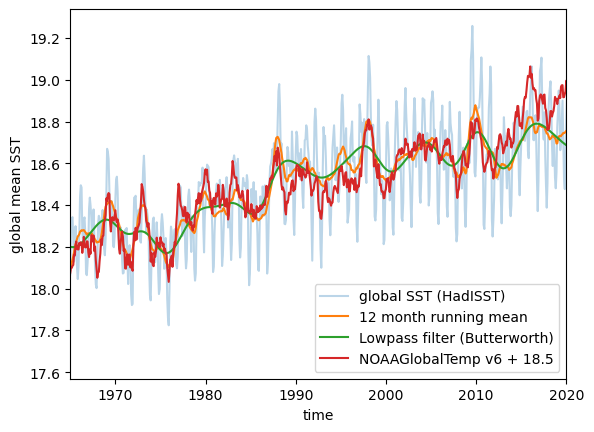

In [14]:
# plot the time series
time=np.arange(1870,2025+1/12,1/12)
# running mean (12 months)
gsstm=movmean(gsst,12)
# plot
plt.plot(time,gsst,alpha=.3,label='global SST (HadISST)')
plt.plot(time[6:-6],gsstm[6:-6],label='12 month running mean')
plt.plot(time,gsstlp,label='Lowpass filter (Butterworth)')
plt.plot(time1,SST+18.5,label='NOAAGlobalTemp v6 + 18.5')
plt.xlim(1965,2020)
plt.legend()
plt.xlabel('time')
plt.ylabel('global mean SST')
plt.savefig('SST_figure.pdf',bbox_inches='tight')

In [15]:
time1=np.arange('1850-01','2025-06',dtype='datetime64[M]')

In [25]:
da=xr.DataArray(data=SST,name='SST',dims=['time'],coords={'time':time1})

In [17]:
ds=da.to_dataset()
ds.to_netcdf('NOAA_Global_SST.nc')

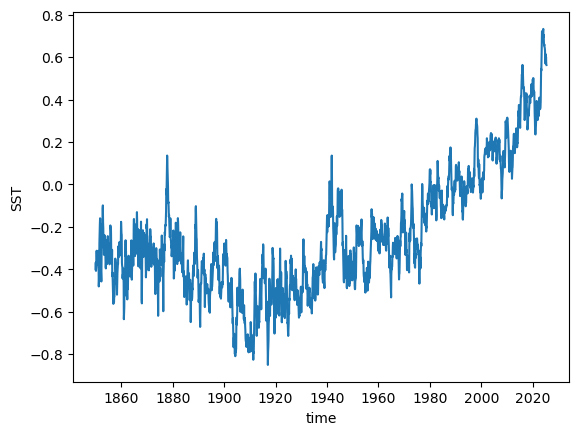

In [18]:
ds.SST.plot()